# Strategy Exporter

Pick a run + strategy below, run all cells. Converts the selected strategy into a
standalone Python class (matching the `StratGen*` format used by the GA optimizer
framework: `domain()` / `validate(p)` / `signals(df, p)`) and saves it as a `.py` file.

`domain()` in the generated class is a logical search neighborhood around each
parameter's actual value (multiplicative + small additive steps, clamped to the same
bounds local_quant_ai enforces at generation time) -- not just the single value the
source strategy used -- so a GA optimizer has something real to search over.

Note: exported strategies only ever define LONG entry/exit logic (local_quant_ai's
schema has no separate short entry/exit), so `short_entry`/`short_exit` in the
generated class are always all-False -- not inferred by mirroring the long conditions.


In [1]:
import os, sys, json
import importlib.util
from pathlib import Path

import pandas as pd

# Notebook is expected to live in the project root (next to config.yaml).
PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)  # data/config paths in config.yaml are relative to project root

from src.config import load_config
from src.data_loader import load_symbol
from src.schema import validate_strategy_dict
from src.strategy_export import generate_class_source, _slug
from src.indicators import apply_indicators
from src.rules import compute_signals
from src.backtester import run_backtest

cfg = load_config("config.yaml")

## 1. Pick a run and a strategy

`RUN_DIR` defaults to the most recent run under `results/`. Strategy definitions live in
that run's `llm_iterations/iteration_*_strategies.json` files (every strategy that was
generated, not just accepted ones); `all_experiments.csv` has the outcome for each.


In [ ]:
RESULTS_DIR = PROJECT_ROOT / "results"
# run dir using the folder name
RUN_DIR = RESULTS_DIR / "local_quant_run_20260904_104641_3d805e"  # <- change to pick a different run
# RUN_DIR = sorted(RESULTS_DIR.iterdir())[-1]  # <- change to pick a different run

print("Using run:", RUN_DIR.name)

def load_all_strategies(run_dir: Path) -> dict:
    """(iteration, strategy_name) -> raw strategy dict, scanning every iteration file
    in the run. Keyed by iteration too (not just name) because the LLM sometimes
    reuses a strategy_name across iterations without a version suffix, which would
    otherwise silently collide."""
    found = {}
    for f in sorted((run_dir / "llm_iterations").glob("iteration_*_strategies.json")):
        iteration = int(f.name.split("_")[1])
        for item in json.loads(f.read_text(encoding="utf-8")):
            if item.get("strategy_name"):
                found[(iteration, item["strategy_name"])] = item
    return found

strategies_by_iter_name = load_all_strategies(RUN_DIR)

experiments = pd.read_csv(RUN_DIR / "accepted_strategies.csv")
summary = (
    experiments[["strategy_name", "status", "avg_fold_sharpe", "min_fold_sharpe", "sharpe_consistency"]]
    .drop_duplicates(subset="strategy_name")
    .set_index("strategy_name")
)

# Browse by row index (the number on the left below == the row index to use in the
# next cell, and also matches the row position in all_experiments.csv itself, minus
# the header line).
display_cols = ["iteration", "strategy_name", "status", "avg_fold_sharpe", "min_fold_sharpe", "sharpe_consistency"]
print(experiments[display_cols].to_string())

Using run: local_quant_run_20260904_104641_3d805e
   iteration                            strategy_name    status  avg_fold_sharpe  min_fold_sharpe  sharpe_consistency
0         31    ema_trend_long_short_v12_v6_faster v5  accepted         0.573065         0.279171            0.487153
1         42  ema_trend_long_short_v12_v9_atr_size v5  accepted         0.473729         0.332268            0.701387
2         46          ema_trend_ls_dual_filter_atr v7  accepted         0.448538         0.224190            0.499825


In [16]:
STRATEGY_INDEX = 2  # <- row index from the table printed above (or from all_experiments.csv, 0-based, header excluded)

row = experiments.loc[STRATEGY_INDEX]
STRATEGY_NAME = row["strategy_name"]
iteration = int(row["iteration"])

raw_strategy = strategies_by_iter_name[(iteration, STRATEGY_NAME)]
strategy, problems = validate_strategy_dict(raw_strategy)
if problems:
    raise ValueError(f"Strategy failed validation: {problems}")

print(f"Row {STRATEGY_INDEX}  (iteration {iteration}, status={row['status']}): {strategy.strategy_name}  ({strategy.symbol})")
print(strategy.rationale)

Row 2  (iteration 46, status=accepted): ema_trend_ls_dual_filter_atr v7  (@TY)
Refinement of v3 with shorter cross (10/40) to fire more often and lift fold-5 trades above 15, plus a 50-EMA regime filter. Wider 0.015 stop. Slightly faster trend definition should keep avg Sharpe near v3's level while raising worst-fold trade count.


## 2. Generate the class source


In [17]:
source = generate_class_source(raw_strategy)
print(source)

from __future__ import annotations

from typing import Any, Dict, List, Tuple

import numpy as np
import pandas as pd

Signals = Tuple[pd.Series, pd.Series, pd.Series, pd.Series]


class StratGenEmaTrendLsDualFilterAtrV7:
    """
    ema_trend_ls_dual_filter_atr v7 (@TY, 1d)

    Refinement of v3 with shorter cross (10/40) to fire more often and lift fold-5 trades above 15, plus a 50-EMA regime filter. Wider 0.015 stop. Slightly faster trend definition should keep avg Sharpe near v3's level while raising worst-fold trade count.

    Auto-generated from a local_quant_ai strategy JSON. Trades both long and short (short_entry/short_exit are real rules from the source strategy).

    stop_loss_pct=0.015, take_profit_pct=None,
    position_sizing='risk_based_contracts', risk_per_trade=0.01
    (risk/exit-price management is not part of this class -- wire it through
    your own backtester's position sizing / stop-loss handling as usual.)
    """

    MODE = "ema_trend_ls_dual_filter_atr_v7"

## 3. Save to a .py file


In [18]:
EXPORT_DIR = RUN_DIR / "exported_strategies"
EXPORT_DIR.mkdir(exist_ok=True)

out_path = EXPORT_DIR / f"strat_gen_{_slug(strategy.strategy_name)}.py"
out_path.write_text(source, encoding="utf-8")
print("Saved to:", out_path)

Saved to: d:\3dari\Desktop\local_quant_ai\results\local_quant_run_20260904_104641_3d805e\exported_strategies\strat_gen_ema_trend_ls_dual_filter_atr_v7.py


## 4. Sanity-check: import the exported class and run it against real data

Confirms the generated file isn't just syntactically valid -- it actually imports cleanly
and produces signals when run standalone (no local_quant_ai imports needed at this point).


In [19]:
spec = importlib.util.spec_from_file_location("exported_strategy", out_path)
module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(module)

class_name = [n for n in dir(module) if n.startswith("StratGen")][0]
cls = getattr(module, class_name)

# Use the strategy's actual parameter values, not domain()[0] -- domain()[0] is just
# the smallest widened candidate for each parameter independently, and combinations
# of those can be degenerate (e.g. a stochastic smooth_d of 1 makes %K == %D, so
# crossover-based entries can never fire even though the real strategy trades fine).
p = cls.default_params()
assert cls.validate(p)

df, _meta = load_symbol(strategy.symbol, cfg)
le, lx, se, sx = cls.signals(df, p)

print(f"{class_name}")
print(f"  MODE={cls.MODE!r}  TAG={cls.TAG!r}  REQUIRED_COLS={cls.REQUIRED_COLS}")
print(f"  params (source strategy's actual values): {p}")
print(f"  long_entry signals:  {int(le.sum())}")
print(f"  long_exit signals:   {int(lx.sum())}")
if strategy.has_short_logic:
    print(f"  short_entry signals: {int(se.sum())}")
    print(f"  short_exit signals:  {int(sx.sum())}")
else:
    print(f"  short_entry/short_exit: always False (strategy is long-only)")
    assert not se.any() and not sx.any()

StratGenEmaTrendLsDualFilterAtrV7
  MODE='ema_trend_ls_dual_filter_atr_v7'  TAG='getldfav'  REQUIRED_COLS=['close', 'high', 'low']
  params (source strategy's actual values): {'ema_close_period': 10, 'ema_close_period_2': 40, 'ema_close_period_3': 50, 'atr_period': 14}
  long_entry signals:  77
  long_exit signals:   2604
  short_entry signals: 79
  short_exit signals:  3320


## 5. PnL check: exported strategy vs. internal (strategy JSON) vs. Buy & Hold

Draws two strategy equity curves side by side, plus a benchmark, all for `strategy.symbol`
only (not a portfolio-wide comparison):

- **Exported (standalone)**: signals from the exported `.py` class (`cls.signals`) run
  through `run_backtest`.
- **Internal (strategy JSON)**: signals computed the same way `pnl_viewer.ipynb` and
  `src/orchestrator.py` do it -- `compute_signals(apply_indicators(df, indicator_defs),
  strategy)` straight from the strategy's JSON definition -- run through the same
  `run_backtest`.
- **Buy & Hold**: `close` rescaled to the same starting equity, for reference.

If the export is faithful, the two strategy lines should sit on top of each other. Note
this is a single whole-history backtest (no fold-splitting/holdout), unlike
`pnl_viewer.ipynb`'s chained multi-fold view -- it's here purely to check the exported
class reproduces the source strategy, not to re-validate the acceptance criteria.


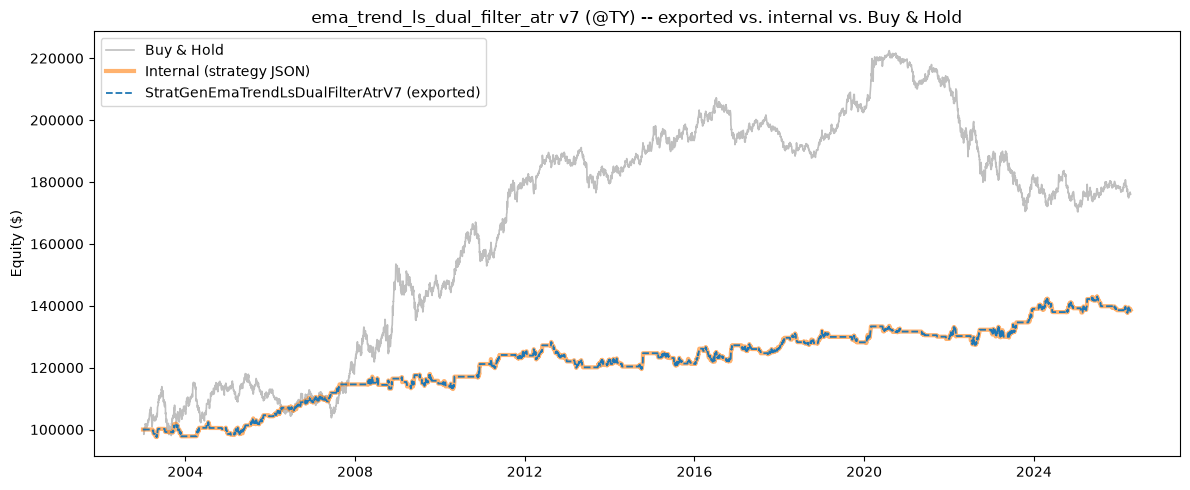

                      Exported      Internal    Buy & Hold
Final equity           138,676       138,676       176,072
Total return %            38.7          38.7          76.1
# trades                   156           156              

Max equity-curve difference (exported vs internal): 0.00  -- match


In [20]:
%matplotlib inline
import matplotlib.pyplot as plt

# --- Exported (standalone) class, run through the real backtester ---
df_exported = df.copy()
df_exported["entry_signal"] = le
df_exported["exit_signal"] = lx
df_exported["short_entry_signal"] = se
df_exported["short_exit_signal"] = sx
exported_result = run_backtest(df_exported, strategy, cfg, strategy.symbol)
exported_equity = exported_result.equity_curve["equity"]

# --- Internal: signals straight from the strategy JSON, same as pnl_viewer.ipynb ---
indicator_defs = [{"name": i.name, "column": i.column, "params": i.params} for i in strategy.indicators]
df_internal = compute_signals(apply_indicators(df, indicator_defs), strategy)
internal_result = run_backtest(df_internal, strategy, cfg, strategy.symbol)
internal_equity = internal_result.equity_curve["equity"]

initial_capital = float(cfg.backtest.get("initial_capital", 100_000))
buy_hold = df["close"] / df["close"].iloc[0] * initial_capital

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(buy_hold.index, buy_hold.values, color="grey", alpha=0.5, linewidth=1.2, label="Buy & Hold")
ax.plot(internal_equity.index, internal_equity.values, color="tab:orange", linewidth=3,
        alpha=0.6, label="Internal (strategy JSON)")
ax.plot(exported_equity.index, exported_equity.values, color="tab:blue", linewidth=1.3,
        linestyle="--", label=f"{class_name} (exported)")
ax.set_title(f"{strategy.strategy_name} ({strategy.symbol}) -- exported vs. internal vs. Buy & Hold")
ax.set_ylabel("Equity ($)")
ax.legend()
fig.tight_layout()
plt.show()

print(f"{'':16}{'Exported':>14}{'Internal':>14}{'Buy & Hold':>14}")
print(f"{'Final equity':16}{exported_equity.iloc[-1]:>14,.0f}{internal_equity.iloc[-1]:>14,.0f}{buy_hold.iloc[-1]:>14,.0f}")
print(f"{'Total return %':16}{(exported_equity.iloc[-1]/initial_capital-1)*100:>14.1f}"
      f"{(internal_equity.iloc[-1]/initial_capital-1)*100:>14.1f}{(buy_hold.iloc[-1]/initial_capital-1)*100:>14.1f}")
print(f"{'# trades':16}{exported_result.summary['num_trades']:>14}{internal_result.summary['num_trades']:>14}{'':>14}")

max_diff = (exported_equity - internal_equity).abs().max()
print(f"\nMax equity-curve difference (exported vs internal): {max_diff:,.2f}"
      + ("  -- match" if max_diff < 1e-6 else "  -- MISMATCH, export does not reproduce the source strategy"))